**LAB EXPERIMENT - 9**\
**Recommendation Systems using Collaborative Filtering Techniques**

Name : Poovika M\
Roll No : 24BAD087

**SCENARIO 1**

**CODE INTERPRETATION**

1. Import Libraries

     Libraries are imported for:

    => Data handling (pandas, numpy)\
    => Similarity computation (cosine similarity)\
    => Evaluation (RMSE, MAE)\
    => Visualization (matplotlib, seaborn)

2. Load Dataset

    The ratings dataset is loaded and inspected using:

    => read_csv()\
    => head()

    Columns are renamed for better understanding.

3. Reduce Dataset Size

    A subset of 20,000 rows is selected using sampling to reduce computation time.

4. Data Inspection

    Dataset is checked using:

    => info()\
    => isnull()

    This verifies structure and missing values.

5. Reduce Sparsity

    To improve performance:

    => Active users (>20 ratings) are selected\
    => Popular movies (>20 ratings) are selected

    Dataset is filtered to reduce sparsity.

6. Create User-Item Matrix

    A pivot table is created where:

    => Rows represent users\
    => Columns represent movies\
    => Values represent ratings\

7. Handle Missing Values

    Missing values are replaced with 0 for similarity calculation.

8. Compute User Similarity

    Cosine similarity is applied to compute similarity between users.

9. Find Similar Users

    Top 5 similar users are identified for a given user using similarity scores.

10. Predict Ratings

    Ratings are predicted using weighted average of ratings from similar users.

11. Generate Recommendations

    Movies not yet rated by the user are recommended based on predicted ratings.

12. Train-Test Split

    Dataset is divided into:

    => 80% training data\
    => 20% testing data

13. Evaluation Metrics

    Model performance is measured using:

    => RMSE\
    => MAE

14. Sparsity Analysis

    Sparsity of the user-item matrix is calculated to measure missing values.

15. Visualization

    => Heatmap of user-item matrix\
    => User similarity matrix\
    => Bar chart for top recommendations

**CONCLUSION**

  The program applies user-based collaborative filtering using KNN to recommend movies. It computes similarity between users, predicts ratings, and generates recommendations. Performance is evaluated using RMSE and MAE.

POOVIKA M - 24BAD087
Dataset Loaded Successfully
   user_id  movie_id  rating   timestamp
0        1       110     1.0  1425941529
1        1       147     4.5  1425942435
2        1       858     5.0  1425941523
3        1      1221     5.0  1425941546
4        1      1246     5.0  1425941556

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 33553 to 42326
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   user_id    20000 non-null  int64  
 1   movie_id   20000 non-null  int64  
 2   rating     20000 non-null  float64
 3   timestamp  20000 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 781.2 KB
None

Missing Values:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64

Filtered Data Shape: (4443, 4)
User-Item Matrix Shape: (218, 162)

Top Recommendations for User 4:
movie_id
150     2.505504
733     2.155048
185     2.082945
6377    2.035239
2028    2.017439
10

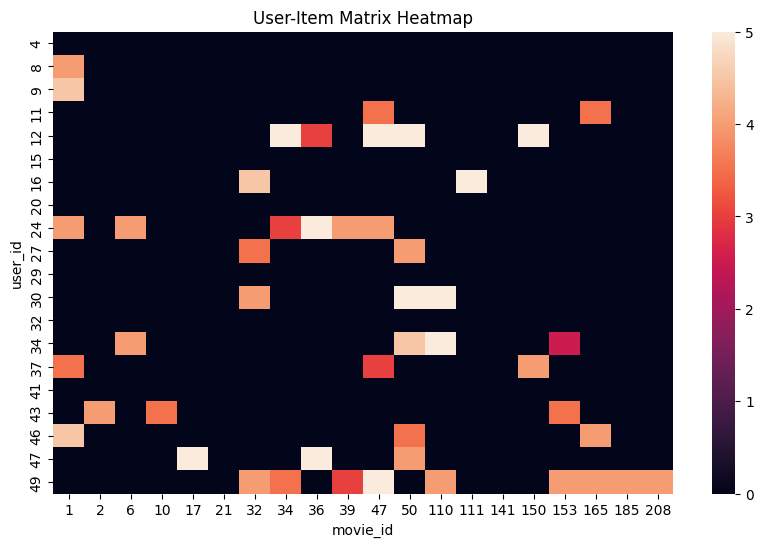

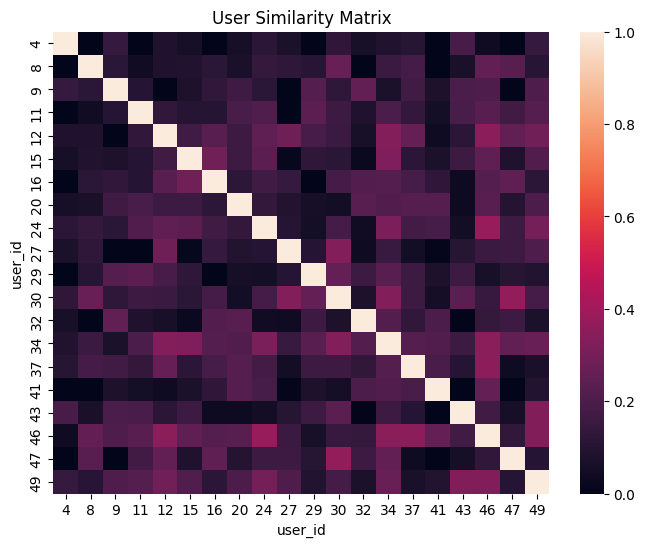

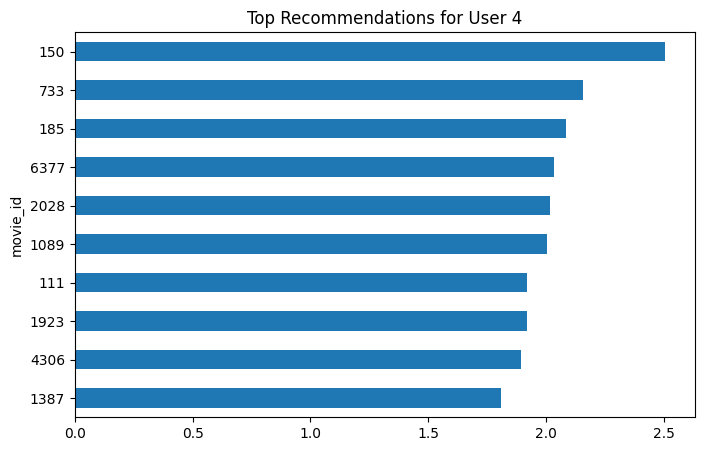

In [1]:
# POOVIKA M - 24BAD087
# USER-BASED COLLABORATIVE FILTERING (KNN)

print("POOVIKA M - 24BAD087")
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns


#Load Dataset
ratings = pd.read_csv(
    "/content/sample_data/ratings.csv",
    nrows=50000
)

#Rename columns
ratings.rename(columns={
    'userId': 'user_id',
    'movieId': 'movie_id'
}, inplace=True)

print("Dataset Loaded Successfully")
print(ratings.head())


#Reduce Dataset Size
data = ratings.sample(n=20000, random_state=42)


#Data Inspection
print("\nDataset Info:")
print(data.info())

print("\nMissing Values:")
print(data.isnull().sum())


#Reduce Sparsity (Fix Memory Issue)
# Keep active users
user_counts = data['user_id'].value_counts()
active_users = user_counts[user_counts > 20].index

#Keep popular movies
movie_counts = data['movie_id'].value_counts()
popular_movies = movie_counts[movie_counts > 20].index

#Filter dataset
data_filtered = data[
    (data['user_id'].isin(active_users)) &
    (data['movie_id'].isin(popular_movies))
]

print("\nFiltered Data Shape:", data_filtered.shape)


#Create User-Item Matrix
user_item_matrix = data_filtered.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
)

print("User-Item Matrix Shape:", user_item_matrix.shape)


# Handle Missing Values
user_item_filled = user_item_matrix.fillna(0)


#Compute User Similarity (Cosine)
user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)


#Find Top-N Similar Users
def get_similar_users(user_id, n=5):
    if user_id not in user_similarity_df.index:
        return None
    return user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]


#Predict Ratings
def predict_ratings(user_id):
    if user_id not in user_item_matrix.index:
        return None

    similar_users = get_similar_users(user_id, n=5)

    weighted_sum = np.zeros(user_item_matrix.shape[1])
    similarity_sum = np.zeros(user_item_matrix.shape[1])

    for sim_user, similarity in similar_users.items():
        user_ratings = user_item_filled.loc[sim_user].values

        weighted_sum += similarity * user_ratings
        similarity_sum += similarity

    predicted_ratings = weighted_sum / (similarity_sum + 1e-9)

    return pd.Series(predicted_ratings, index=user_item_matrix.columns)


#Generate Recommendations
def recommend_movies(user_id, n=10):
    predicted_ratings = predict_ratings(user_id)

    if predicted_ratings is None:
        return "User not found"

    rated_movies = user_item_matrix.loc[user_id].dropna().index

    recommendations = predicted_ratings.drop(rated_movies)

    return recommendations.sort_values(ascending=False).head(n)


#Example Recommendation
sample_user = user_item_matrix.index[0]

print(f"\nTop Recommendations for User {sample_user}:")
print(recommend_movies(sample_user))


#Train-Test Split
train, test = train_test_split(data_filtered, test_size=0.2, random_state=42)


#Evaluation (RMSE & MAE)
actual = []
predicted = []

for row in test.itertuples():
    user = row.user_id
    movie = row.movie_id

    if user in user_item_matrix.index and movie in user_item_matrix.columns:
        pred = predict_ratings(user)[movie]

        actual.append(row.rating)
        predicted.append(pred)

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nEvaluation Metrics:")
print("RMSE:", rmse)
print("MAE:", mae)

#Sparsity Analysis
sparsity = 1 - (np.count_nonzero(user_item_matrix) / user_item_matrix.size)
print("\nSparsity of Matrix:", sparsity)

#VISUALIZATION

#Heatmap of User-Item Matrix
plt.figure(figsize=(10,6))
sns.heatmap(user_item_filled.iloc[:20, :20])
plt.title("User-Item Matrix Heatmap")
plt.show()


#Similarity Matrix
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.title("User Similarity Matrix")
plt.show()


#Top Recommendations Plot
recs = recommend_movies(sample_user)

if isinstance(recs, pd.Series):
    recs.plot(kind='barh', figsize=(8,5))
    plt.title(f"Top Recommendations for User {sample_user}")
    plt.gca().invert_yaxis()
    plt.show()


**SCENARIO 2**

**CODE INTERPRETATION**

1. Import Libraries

    Libraries are imported for:

    => Data handling (pandas, numpy)\
    => Similarity computation (cosine similarity)\
    => Evaluation (RMSE)\
    => Visualization (matplotlib, seaborn)

2. Load Dataset

    The ratings dataset is loaded and inspected using:

    => read_csv()\
    => head()

    Columns are renamed (userId → user_id, movieId → movie_id).

3. Reduce Sparsity

    To improve performance:

    => Active users (>20 ratings) are selected\
    => Popular movies (>20 ratings) are selected

    Dataset is filtered to remove sparse data.

4. Create Item-User Matrix

    A pivot table is created where:

    => Rows represent movies (items)\
    => Columns represent users\
    => Values represent ratings

5. Handle Missing Values

    Missing values are replaced with 0 for similarity calculation.

6. Compute Item Similarity

    Cosine similarity is applied to compute similarity between items.

7. Identify Similar Items

    Top similar items are identified for a given movie using similarity scores.

8. Recommend Items

    Recommendations are generated based on user’s previously rated items and similar items.

9. Example Recommendation

    Recommended movies are displayed for a sample user.

10. Evaluation (RMSE)

    Model performance is evaluated using RMSE by comparing predicted and actual ratings.

11. Precision@K

    Precision@K is calculated to measure relevance of recommended items.

12. Visualization

    => Item similarity heatmap\
    => Top similar items graph\
    => Recommended items bar chart

**CONCLUSION**

  The program applies item-based collaborative filtering to recommend similar movies. It computes similarity between items and generates recommendations based on user history. Performance is evaluated using RMSE and Precision@K, and visualizations help analyze similarity patterns.

POOVIKA M - 24BAD087
Dataset Loaded
   user_id  movie_id  rating
0        1       110     1.0
1        1       147     4.5
2        1       858     5.0
3        1      1221     5.0
4        1      1246     5.0
Filtered Data Shape: (26571, 3)
Item-User Matrix Shape: (658, 321)

Similar Movies to Movie 1:
movie_id
356     0.622292
1270    0.614329
1210    0.607430
2571    0.599622
780     0.594153
Name: 1, dtype: float64

Recommended Movies for User 1:
89745    10.502354
2571      7.960408
88125     7.280133
40815     6.438152
60069     6.323548
54001     6.238010
1193      6.151756
1196      5.960084
1265      5.632705
79132     5.611769
dtype: float64

Not enough data for RMSE

Precision@5: 0.0


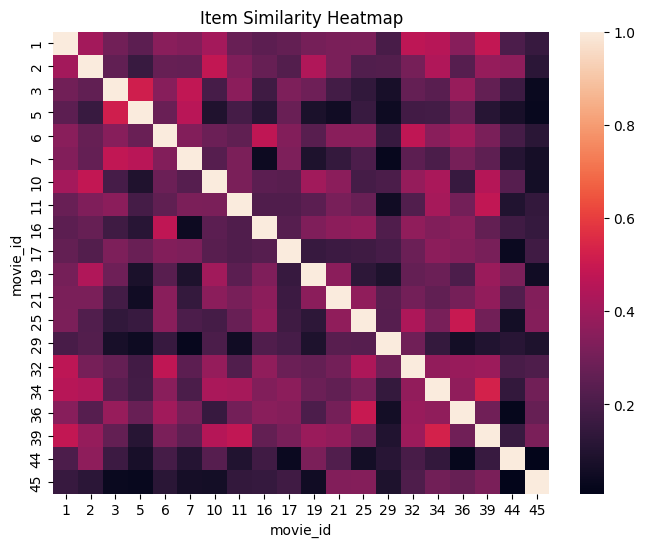

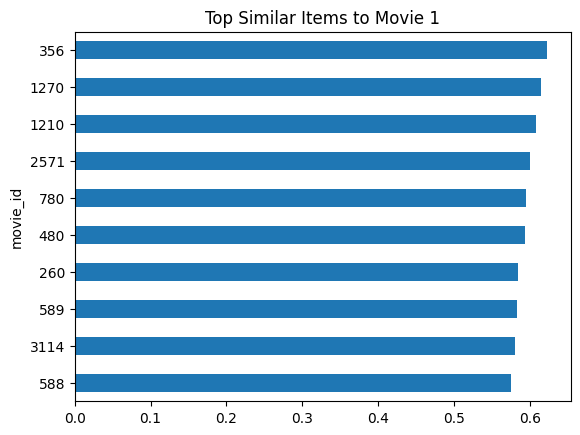

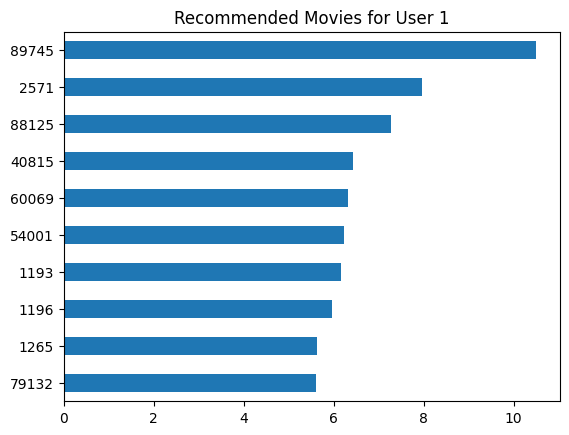

In [3]:
# POOVIKA M - 24BAD087
# ITEM-BASED COLLABORATIVE FILTERING

print("POOVIKA M - 24BAD087")
#Import Libraries
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

#Load Dataset
ratings = pd.read_csv(
    "/content/sample_data/ratings.csv",
    usecols=['userId', 'movieId', 'rating'],
    nrows=50000   # limit data
)

#Rename columns
ratings.rename(columns={
    'userId': 'user_id',
    'movieId': 'movie_id'
}, inplace=True)

print("Dataset Loaded")
print(ratings.head())

#Reduce Sparsity
user_counts = ratings['user_id'].value_counts()
active_users = user_counts[user_counts > 20].index

movie_counts = ratings['movie_id'].value_counts()
popular_movies = movie_counts[movie_counts > 20].index

data = ratings[
    (ratings['user_id'].isin(active_users)) &
    (ratings['movie_id'].isin(popular_movies))
]

print("Filtered Data Shape:", data.shape)

#Create ITEM-USER Matrix (Transpose!)
item_user_matrix = data.pivot_table(
    index='movie_id',
    columns='user_id',
    values='rating'
)

print("Item-User Matrix Shape:", item_user_matrix.shape)

#Fill Missing Values
item_user_filled = item_user_matrix.fillna(0)

#Compute Item Similarity
item_similarity = cosine_similarity(item_user_filled)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_user_matrix.index,
    columns=item_user_matrix.index
)

#Get Similar Items
def get_similar_items(movie_id, n=5):
    if movie_id not in item_similarity_df.index:
        return "Movie not found"

    similar_items = item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]
    return similar_items


print("\nSimilar Movies to Movie 1:")
print(get_similar_items(item_user_matrix.index[0]))

#Recommend Items for a User
def recommend_items(user_id, n=10):
    if user_id not in item_user_matrix.columns:
        return "User not found"

    user_ratings = item_user_matrix[user_id].dropna()

    scores = pd.Series(dtype=float)

    for movie, rating in user_ratings.items():
        similar_items = get_similar_items(movie, n=5)

        for sim_movie, similarity in similar_items.items():
            if sim_movie not in user_ratings:
                scores[sim_movie] = scores.get(sim_movie, 0) + similarity * rating

    return scores.sort_values(ascending=False).head(n)

#Example Recommendation
sample_user = item_user_matrix.columns[0]

print(f"\nRecommended Movies for User {sample_user}:")
print(recommend_items(sample_user))

#Evaluation (RMSE)
actual = []
predicted = []

for user in item_user_matrix.columns[:50]:  # limit users
    recs = recommend_items(user, n=5)

    if isinstance(recs, pd.Series):
        for movie in recs.index:
            if movie in item_user_matrix.index:
                pred = recs[movie]
                actual_rating = item_user_matrix.loc[movie, user]

                if not np.isnan(actual_rating):
                    actual.append(actual_rating)
                    predicted.append(pred)

if len(actual) > 0:
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    print("\nRMSE:", rmse)
else:
    print("\nNot enough data for RMSE")

#Precision@K
def precision_at_k(user_id, k=5):
    recommended = recommend_items(user_id, n=k)

    if not isinstance(recommended, pd.Series):
        return 0

    relevant = 0
    total = k

    for movie in recommended.index:
        if movie in item_user_matrix.index:
            if item_user_matrix.loc[movie, user_id] >= 3:  # relevant threshold
                relevant += 1

    return relevant / total


print("\nPrecision@5:", precision_at_k(sample_user))

#VISUALIZATION

#Item Similarity Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Heatmap")
plt.show()

#Top Similar Items Graph
movie_id = item_user_matrix.index[0]
similar_items = get_similar_items(movie_id, n=10)

if isinstance(similar_items, pd.Series):
    similar_items.plot(kind='barh')
    plt.title(f"Top Similar Items to Movie {movie_id}")
    plt.gca().invert_yaxis()
    plt.show()

#Recommendation Scores Chart
recs = recommend_items(sample_user)

if isinstance(recs, pd.Series):
    recs.plot(kind='barh')
    plt.title(f"Recommended Movies for User {sample_user}")
    plt.gca().invert_yaxis()
    plt.show()
